<a href="https://colab.research.google.com/github/AasirR/CDAZZDEV-MLE-AasirWaseer/blob/main/task1_financial/task1_financial_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 — Financial AI: LLM-Powered Equity Research Assistant
### CDAZZDEV Senior Machine Learning Engineer Assessment
**Candidate:** Aasir Waseer  
**Repository:** `CDAZZDEV-MLE-AasirWaseer`  

---

## Overview
This notebook implements a full LLM-powered equity research assistant that:
- **Task 1A**: Ingests real financial data, computes 5 technical indicators from first principles, retrieves news headlines, and produces a structured summary dictionary.
- **Task 1B**: Uses a free LLM API (Groq) to perform per-headline sentiment analysis and generate a reasoned Buy/Hold/Sell signal — with full Pydantic validation and clean prompt engineering.
- **Bonus**: Renders a one-page equity research brief as styled HTML with an embedded chart.

**Ticker chosen:** `AAPL` (Apple Inc.) — chosen for liquidity, data quality, and broad analyst coverage.


## Environment Setup

In [1]:
# Install dependencies (Colab-compatible)
# AI-ASSISTED: Claude (claude-sonnet-4-20250514), Prompt: 'Identify required pip packages for yfinance, groq, pydantic pipeline', Date: 2026-05-13
!pip install -q yfinance groq pydantic requests pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.4 MB/s eta 0:00:00


In [2]:
import os
import json
import logging
import warnings
from datetime import datetime, timedelta
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import requests
from groq import Groq
from pydantic import BaseModel, Field, field_validator, ValidationError

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# ── Configuration ───────────────────────────────────────────────────────────
TICKER = "AAPL"                        # Chosen ticker
LOOKBACK_YEARS = 2                     # Minimum 2 years of OHLCV history
NEWS_COUNT = 10                        # Minimum 10 headlines

# Groq API key — set via environment variable; never hardcode credentials
# In Colab: use userdata.get() or set the secret in the Secrets panel
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
except Exception:
    GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '')

print(f"Ticker: {TICKER}")
print(f"Groq API key loaded: {'Yes' if GROQ_API_KEY else 'NO — set GROQ_API_KEY env var or Colab secret'}")

Ticker: AAPL
Groq API key loaded: Yes


---
## Task 1A — Financial Data Pipeline

### 1A-1: OHLCV Data Fetch (≥2 years)

In [3]:
def fetch_ohlcv(ticker: str, years: int = 2) -> pd.DataFrame:
    """
    Fetch daily OHLCV data for `ticker` covering the last `years` years.
    Date range is computed dynamically — no hardcoded date strings.
    Returns a clean DataFrame indexed by date.
    """
    end_date = datetime.today()
    start_date = end_date - timedelta(days=365 * years + 10)  # +10 day buffer

    logger.info(f"Fetching OHLCV for {ticker}: {start_date.date()} → {end_date.date()}")
    raw = yf.download(ticker, start=start_date.strftime('%Y-%m-%d'),
                      end=end_date.strftime('%Y-%m-%d'), progress=False)

    if raw.empty:
        raise ValueError(f"No OHLCV data returned for ticker '{ticker}'")

    # Flatten multi-level columns produced by yfinance (e.g. ('Close', 'AAPL') → 'Close')
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    # Keep only standard OHLCV columns; drop any unexpected extras
    ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    df = raw[[c for c in ohlcv_cols if c in raw.columns]].copy()
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

    logger.info(f"Fetched {len(df)} trading days of OHLCV data.")
    return df


ohlcv = fetch_ohlcv(TICKER, years=LOOKBACK_YEARS)
print(f"Shape: {ohlcv.shape}")
print(f"Date range: {ohlcv.index[0].date()} → {ohlcv.index[-1].date()}")
ohlcv.tail()

Shape: (507, 5)
Date range: 2024-05-03 → 2026-05-12


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-05-06,281.660510,287.764872,280.811287,287.245361,58336100
2026-05-07,289.003717,291.861100,285.516939,287.175415,45224300
2026-05-08,289.743067,294.488695,289.733067,293.050018,52692800
2026-05-11,291.980011,293.880005,290.230011,292.679993,42247300
2026-05-12,292.755005,295.269989,292.614990,294.799988,43943518


### 1A-2: Technical Indicators (computed from first principles — no TA-Lib)

In [4]:
# AI-ASSISTED: Claude (claude-sonnet-4-20250514), Prompt: 'Implement RSI with Wilder smoothing and MACD from first principles in pandas', Date: 2026-05-13

def compute_sma(series: pd.Series, window: int) -> pd.Series:
    """
    Simple Moving Average — arithmetic mean over a rolling window.
    Window-1 leading values are NaN by design (insufficient history).
    """
    return series.rolling(window=window, min_periods=window).mean()


def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    Relative Strength Index using Wilder's smoothing (exponential moving average
    with alpha = 1/period), as per the original Wilder (1978) specification.

    Formula:
        RS  = avg_gain / avg_loss  (Wilder-smoothed)
        RSI = 100 - 100 / (1 + RS)
    """
    delta = series.diff()                        # Day-over-day price change
    gain = delta.clip(lower=0)                   # Positive changes only
    loss = (-delta).clip(lower=0)                # Absolute negative changes

    # Wilder smoothing: seed with simple mean for first `period` bars,
    # then apply exponential decay with alpha = 1/period
    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)  # Guard division-by-zero
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_macd(series: pd.Series,
                 fast: int = 12, slow: int = 26, signal: int = 9
                 ) -> tuple[pd.Series, pd.Series, pd.Series]:
    """
    MACD line, Signal line, and Histogram.

    MACD line  = EMA(fast) − EMA(slow)          [standard parameters: 12, 26]
    Signal     = EMA(MACD, signal_window)        [standard: 9]
    Histogram  = MACD − Signal

    All EMAs use adjust=False to match standard charting library behaviour.
    """
    ema_fast   = series.ewm(span=fast,   adjust=False).mean()
    ema_slow   = series.ewm(span=slow,   adjust=False).mean()
    macd_line  = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram  = macd_line - signal_line
    return macd_line, signal_line, histogram


def compute_bollinger_bands(series: pd.Series,
                             window: int = 20, num_std: float = 2.0
                             ) -> tuple[pd.Series, pd.Series, pd.Series]:
    """
    Bollinger Bands: middle band (SMA), upper band, and lower band.

    Upper = SMA + num_std × rolling_std
    Lower = SMA − num_std × rolling_std

    ddof=0 (population std) is the standard convention for Bollinger Bands.
    """
    middle = series.rolling(window=window, min_periods=window).mean()
    std    = series.rolling(window=window, min_periods=window).std(ddof=0)
    upper  = middle + num_std * std
    lower  = middle - num_std * std
    return upper, middle, lower


def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Attach all five required indicators to the OHLCV DataFrame in-place.
    All computations operate on the 'Close' price column.
    """
    close = df['Close']

    df['SMA_50']    = compute_sma(close, window=50)
    df['SMA_200']   = compute_sma(close, window=200)
    df['RSI_14']    = compute_rsi(close, period=14)

    macd, sig, hist = compute_macd(close, fast=12, slow=26, signal=9)
    df['MACD']          = macd
    df['MACD_Signal']   = sig
    df['MACD_Hist']     = hist

    bb_upper, bb_mid, bb_lower = compute_bollinger_bands(close, window=20, num_std=2.0)
    df['BB_Upper']  = bb_upper
    df['BB_Middle'] = bb_mid
    df['BB_Lower']  = bb_lower

    return df


ohlcv = add_indicators(ohlcv)
print("Indicator columns added:")
indicator_cols = ['SMA_50','SMA_200','RSI_14','MACD','MACD_Signal','MACD_Hist','BB_Upper','BB_Middle','BB_Lower']
print(ohlcv[indicator_cols].tail(5).to_string())

Indicator columns added:
Price           SMA_50     SMA_200     RSI_14      MACD  MACD_Signal  MACD_Hist    BB_Upper   BB_Middle    BB_Lower
Date                                                                                                               
2026-05-06  261.889714  255.749552  69.414944  5.989454     4.387249   1.602206  285.386119  269.973267  254.560414
2026-05-07  262.153670  256.117665  69.312010  6.499615     4.809722   1.689893  287.768891  271.319527  254.870162
2026-05-08  262.560695  256.516396  72.941202  7.293873     5.306552   1.987321  291.117920  272.960016  254.802112
2026-05-11  263.135558  256.915220  72.360729  7.803516     5.805945   1.997571  293.538362  274.645944  255.753526
2026-05-12  263.742032  257.324045  73.654347  8.282996     6.301355   1.981641  295.782573  276.456357  257.130140


### 1A-3: News Headlines Retrieval (≥10 headlines)

In [5]:
def fetch_news(ticker: str, n: int = 10) -> list[dict]:
    """
    Retrieve recent news headlines for `ticker` using the yfinance news endpoint.
    Falls back to a GNews RSS feed if yfinance returns fewer than `n` items.
    Returns a list of dicts with keys: title, publisher, link, published.
    """
    headlines = []

    # --- Primary source: yfinance news endpoint ---
    try:
        ticker_obj = yf.Ticker(ticker)
        raw_news = ticker_obj.news or []
        for item in raw_news:
            content = item.get('content', {})
            title = content.get('title') or item.get('title', '')
            if not title:
                continue
            pub_ts = content.get('pubDate') or item.get('providerPublishTime', None)
            if isinstance(pub_ts, (int, float)):
                pub_str = datetime.utcfromtimestamp(pub_ts).strftime('%Y-%m-%d')
            elif isinstance(pub_ts, str):
                pub_str = pub_ts[:10]
            else:
                pub_str = 'N/A'
            headlines.append({
                'title': title.strip(),
                'publisher': content.get('provider', {}).get('displayName', 'yfinance'),
                'link': content.get('canonicalUrl', {}).get('url', ''),
                'published': pub_str
            })
        logger.info(f"yfinance returned {len(headlines)} headlines.")
    except Exception as e:
        logger.warning(f"yfinance news fetch failed: {e}")

    # --- Fallback: GNews RSS (free, no API key) ---
    if len(headlines) < n:
        try:
            import xml.etree.ElementTree as ET
            query = f"{ticker} stock"
            rss_url = f"https://news.google.com/rss/search?q={query}&hl=en-US&gl=US&ceid=US:en"
            resp = requests.get(rss_url, timeout=10,
                                headers={'User-Agent': 'Mozilla/5.0'})
            resp.raise_for_status()
            root = ET.fromstring(resp.content)
            items = root.findall('.//item')
            for item in items:
                title_el = item.find('title')
                pub_el   = item.find('pubDate')
                link_el  = item.find('link')
                if title_el is None:
                    continue
                headlines.append({
                    'title': title_el.text.strip(),
                    'publisher': 'Google News RSS',
                    'link': link_el.text if link_el is not None else '',
                    'published': pub_el.text[:16] if pub_el is not None else 'N/A'
                })
            logger.info(f"After RSS fallback: {len(headlines)} total headlines.")
        except Exception as e:
            logger.warning(f"RSS fallback failed: {e}")

    if not headlines:
        logger.error("No headlines retrieved from any source.")
        return []

    # Deduplicate and cap at requested count
    seen, unique = set(), []
    for h in headlines:
        if h['title'] not in seen:
            seen.add(h['title'])
            unique.append(h)
    return unique[:max(n, len(unique))]  # Return all available, minimum n


news_items = fetch_news(TICKER, n=NEWS_COUNT)
print(f"\nRetrieved {len(news_items)} headlines for {TICKER}:")
for i, h in enumerate(news_items, 1):
    print(f"  {i:2d}. [{h['published']}] {h['title']}")


Retrieved 10 headlines for AAPL:
   1. [2026-05-12] Tesla stock slips ahead of Musk's trip to China with Trump trade delegation
   2. [2026-05-12] The fast food stocks benefitting from value, premium offerings
   3. [2026-05-13] Dow Jones Futures: Nvidia's Huang Joins Trump's China Trip; How To Handle Sandisk, Micron, Intel
   4. [2026-05-13] Nvidia's Jensen Huang joins Trump's China visit
   5. [2026-05-13] Apple’s India Clean Energy Push And AI Plans Test Investor Expectations
   6. [2026-05-12] Why Intel Corporation (INTC) Was One of the Top “Blue Chip” Stocks Suddenly on Fire in April
   7. [2026-05-12] Nvidia’s Huang Wants to Sell Chips to China. Trump Has Other Priorities.
   8. [2026-05-12] Elon Musk To Join Trump On China State Visit. Tesla Stock Sinks.
   9. [2026-05-12] Tower Semiconductor poised for Q1 earnings beat on strong industry trends: Wedbush
  10. [2026-05-12] Intel’s Big Rally Continues, But Much of the Optimism Is Already Priced In


### 1A-4: Summary Dictionary

In [6]:
def derive_momentum_signal(df: pd.DataFrame) -> str:
    """
    Derive a simple momentum signal from the computed indicators.
    Rules (applied to latest available non-NaN row):
      - Bullish:  SMA_50 > SMA_200 AND RSI_14 < 70 AND MACD > MACD_Signal
      - Bearish:  SMA_50 < SMA_200 AND RSI_14 > 30 AND MACD < MACD_Signal
      - Neutral:  otherwise (conflicting signals)
    """
    latest = df.dropna(subset=['SMA_50','SMA_200','RSI_14','MACD','MACD_Signal']).iloc[-1]
    sma_cross  = latest['SMA_50'] > latest['SMA_200']   # Golden cross = bullish
    rsi_ok     = 30 < latest['RSI_14'] < 70              # Not overbought / oversold
    macd_bull  = latest['MACD'] > latest['MACD_Signal']

    bullish_count = sum([sma_cross, rsi_ok and macd_bull])

    if sma_cross and macd_bull and latest['RSI_14'] < 70:
        return "Bullish"
    elif not sma_cross and not macd_bull and latest['RSI_14'] > 30:
        return "Bearish"
    else:
        return "Neutral"


def build_summary(ticker: str, df: pd.DataFrame) -> dict:
    """
    Produce a clean summary dictionary from OHLCV + indicator data.
    All fields are safely extracted; missing / null values are handled
    without raising exceptions.
    """
    ticker_obj = yf.Ticker(ticker)

    # --- Basic info (graceful fallback if info dict unavailable) ---
    try:
        info = ticker_obj.info or {}
    except Exception:
        info = {}

    # Current price — use last close if real-time unavailable
    current_price = info.get('currentPrice') or info.get('regularMarketPrice') or float(df['Close'].iloc[-1])

    # 52-week high / low from yfinance info; fall back to rolling 252-day window
    week52_high = info.get('fiftyTwoWeekHigh')
    week52_low  = info.get('fiftyTwoWeekLow')
    if week52_high is None:
        week52_high = float(df['High'].rolling(252).max().iloc[-1])
    if week52_low is None:
        week52_low  = float(df['Low'].rolling(252).min().iloc[-1])

    # P/E ratio — trailing preferred; may legitimately be None for some tickers
    pe_ratio = info.get('trailingPE') or info.get('forwardPE') or None

    # YTD return: compare last close to first close of the current calendar year
    current_year = datetime.today().year
    ytd_data = df[df.index.year == current_year]['Close']
    if len(ytd_data) >= 2:
        ytd_return = round((float(ytd_data.iloc[-1]) / float(ytd_data.iloc[0]) - 1) * 100, 2)
    else:
        ytd_return = None

    # Latest indicator values (NaN-safe)
    def safe(series: pd.Series) -> Optional[float]:
        val = series.dropna().iloc[-1] if not series.dropna().empty else None
        return round(float(val), 4) if val is not None else None

    summary = {
        'ticker':           ticker,
        'company_name':     info.get('longName', ticker),
        'sector':           info.get('sector', 'N/A'),
        'current_price':    round(current_price, 2),
        '52w_high':         round(week52_high, 2),
        '52w_low':          round(week52_low, 2),
        'pe_ratio':         round(pe_ratio, 2) if pe_ratio else None,
        'ytd_return_pct':   ytd_return,
        'sma_50':           safe(df['SMA_50']),
        'sma_200':          safe(df['SMA_200']),
        'rsi_14':           safe(df['RSI_14']),
        'macd':             safe(df['MACD']),
        'macd_signal':      safe(df['MACD_Signal']),
        'bb_upper':         safe(df['BB_Upper']),
        'bb_lower':         safe(df['BB_Lower']),
        'momentum_signal':  derive_momentum_signal(df),
        'as_of_date':       str(df.index[-1].date())
    }
    return summary


summary = build_summary(TICKER, ohlcv)
print("\n=== Summary Dictionary ===")
for k, v in summary.items():
    print(f"  {k:<22}: {v}")


=== Summary Dictionary ===
  ticker                : AAPL
  company_name          : Apple Inc.
  sector                : Technology
  current_price         : 294.8
  52w_high              : 295.27
  52w_low               : 193.46
  pe_ratio              : 35.73
  ytd_return_pct        : 8.98
  sma_50                : 263.742
  sma_200               : 257.324
  rsi_14                : 73.6543
  macd                  : 8.283
  macd_signal           : 6.3014
  bb_upper              : 295.7826
  bb_lower              : 257.1301
  momentum_signal       : Neutral
  as_of_date            : 2026-05-12


---
## Task 1B — LLM Sentiment and Signal Reasoning

### 1B-1: Pydantic Schemas (structured output contracts)

In [7]:
# AI-ASSISTED: Claude (claude-sonnet-4-20250514), Prompt: 'Design Pydantic v2 models for headline sentiment and trading signal with validators', Date: 2026-05-13

class HeadlineSentiment(BaseModel):
    """Structured sentiment output for a single news headline."""
    headline:      str   = Field(..., description="Original news headline text")
    sentiment:     str   = Field(..., description="One of: positive, negative, neutral")
    confidence:    float = Field(..., ge=0.0, le=1.0, description="Confidence score [0, 1]")
    brief_reason:  str   = Field(..., description="One-sentence explanation of the sentiment")

    @field_validator('sentiment')
    @classmethod
    def sentiment_must_be_valid(cls, v: str) -> str:
        allowed = {'positive', 'negative', 'neutral'}
        v = v.lower().strip()
        if v not in allowed:
            raise ValueError(f"sentiment must be one of {allowed}, got '{v}'")
        return v


class SentimentAggregation(BaseModel):
    """Aggregated sentiment across all headlines."""
    positive_count: int
    negative_count: int
    neutral_count:  int
    overall_score:  float = Field(..., ge=-1.0, le=1.0,
                                  description="Score in [-1, 1]: positive=1, negative=-1, weighted by confidence")
    dominant_sentiment: str


class TradingSignal(BaseModel):
    """LLM-generated trading recommendation with structured reasoning."""
    signal:      str  = Field(..., description="One of: Buy, Hold, Sell")
    confidence:  float = Field(..., ge=0.0, le=1.0)
    reasoning:   str  = Field(..., min_length=100,
                               description="3-5 sentence reasoning over indicator combinations")
    key_risks:   list[str] = Field(..., description="2-3 bullet risks")
    time_horizon: str = Field(default="Short-term (1-4 weeks)")

    @field_validator('signal')
    @classmethod
    def signal_must_be_valid(cls, v: str) -> str:
        allowed = {'Buy', 'Hold', 'Sell'}
        v = v.strip().capitalize()
        if v not in allowed:
            raise ValueError(f"signal must be one of {allowed}, got '{v}'")
        return v


print("Pydantic schemas defined: HeadlineSentiment, SentimentAggregation, TradingSignal")

Pydantic schemas defined: HeadlineSentiment, SentimentAggregation, TradingSignal


### 1B-2: Prompt Templates (separated from business logic)

In [8]:
# Prompt constants — defined once here, never inline in business logic
# AI-ASSISTED: Claude (claude-sonnet-4-20250514), Prompt: 'Write system/user prompts for financial news sentiment and trading signal generation', Date: 2026-05-13

SENTIMENT_SYSTEM_PROMPT = """\
You are a financial news sentiment analyst.
Given a news headline about a publicly traded company, return ONLY a valid JSON object
with exactly these four fields:
  - "headline"     : the original headline (string)
  - "sentiment"    : one of "positive", "negative", "neutral" (string, lowercase)
  - "confidence"   : a float between 0.0 and 1.0 representing your certainty
  - "brief_reason" : a single sentence explaining the sentiment (string)

Output ONLY the JSON object. No markdown fences, no preamble, no explanation.
"""

SENTIMENT_USER_TEMPLATE = """\
Analyse the sentiment of this financial news headline:

Headline: {headline}
"""

SIGNAL_SYSTEM_PROMPT = """\
You are a senior quantitative equity analyst.
You will be given a set of technical indicators and a news sentiment score for a stock.
Your task is to produce a structured trading signal recommendation.

Return ONLY a valid JSON object with exactly these fields:
  - "signal"       : one of "Buy", "Hold", "Sell"
  - "confidence"   : float [0.0, 1.0]
  - "reasoning"    : 3 to 5 sentences reasoning over the COMBINATION of indicators,
                     not merely restating individual values. Explain how they interact.
  - "key_risks"    : list of 2 to 3 specific risk strings
  - "time_horizon" : string describing the signal timeframe (e.g. "Short-term (1-4 weeks)")

Output ONLY the JSON object. No markdown fences, no preamble.
"""

SIGNAL_USER_TEMPLATE = """\
Ticker: {ticker}

Technical Indicators (as of {as_of_date}):
  Current Price : ${current_price}
  52-Week Range : ${w52_low} – ${w52_high}
  YTD Return    : {ytd_return}%
  SMA-50        : ${sma_50}
  SMA-200       : ${sma_200}
  RSI (14)      : {rsi_14}
  MACD          : {macd} (Signal: {macd_signal})
  Bollinger Bands: Upper ${bb_upper} / Lower ${bb_lower}
  Momentum      : {momentum_signal}

News Sentiment Aggregation:
  Overall Score       : {sentiment_score:.2f}  (range -1 bearish → +1 bullish)
  Dominant Sentiment  : {dominant_sentiment}
  Breakdown           : {pos} positive / {neu} neutral / {neg} negative headlines

Based on these indicators working together, provide your structured signal recommendation.
"""

print("Prompt templates loaded.")

Prompt templates loaded.


### 1B-3: LLM Client + Sentiment Analysis

In [12]:
# AI-ASSISTED: Claude (claude-sonnet-4-20250514), Prompt: 'Implement Groq API wrapper with retry, JSON parsing, and Pydantic validation', Date: 2026-05-13

groq_client = Groq(api_key=GROQ_API_KEY)
LLM_MODEL   = "llama-3.3-70b-versatile"   # Groq free-tier model with strong reasoning


def call_llm(system_prompt: str, user_prompt: str,
             max_tokens: int = 512, temperature: float = 0.1) -> str:
    """
    Call the Groq LLM with system and user prompts.
    Returns raw text content. Raises on API errors.
    """
    response = groq_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt}
        ],
        max_tokens=max_tokens,
        temperature=temperature,
    )
    return response.choices[0].message.content.strip()


def parse_and_validate_json(raw: str, model_class: type[BaseModel]) -> Optional[BaseModel]:
    """
    Strip optional markdown fences, parse JSON, and validate against Pydantic model.
    Logs validation failures and returns None rather than raising.
    """
    # Strip ``` fences if the model ignored instructions
    cleaned = raw.strip().removeprefix('```json').removeprefix('```').removesuffix('```').strip()
    try:
        data = json.loads(cleaned)
        return model_class(**data)
    except json.JSONDecodeError as e:
        logger.error(f"JSON parse error: {e} | Raw: {raw[:200]}")
        return None
    except ValidationError as e:
        logger.error(f"Pydantic validation error: {e} | Raw: {raw[:200]}")
        return None


def analyse_headlines(headlines: list[dict]) -> tuple[list[HeadlineSentiment], SentimentAggregation]:
    """
    Run per-headline LLM sentiment analysis.
    Returns validated HeadlineSentiment objects and an aggregation.
    Failed validations are logged and skipped (graceful degradation).
    """
    results: list[HeadlineSentiment] = []
    failed = 0

    for i, item in enumerate(headlines, 1):
        user_prompt = SENTIMENT_USER_TEMPLATE.format(headline=item['title'])
        try:
            raw = call_llm(SENTIMENT_SYSTEM_PROMPT, user_prompt, max_tokens=256)
            validated = parse_and_validate_json(raw, HeadlineSentiment)
            if validated:
                # Ensure headline field matches the original input
                validated.headline = item['title']
                results.append(validated)
                logger.info(f"  [{i:2d}] {validated.sentiment.upper():8s} ({validated.confidence:.2f}) — {item['title'][:60]}")
            else:
                failed += 1
        except Exception as e:
            logger.error(f"LLM call failed for headline {i}: {e}")
            failed += 1

    logger.info(f"Sentiment analysis complete: {len(results)} succeeded, {failed} failed.")

    # --- Aggregate scores ---
    pos = [r for r in results if r.sentiment == 'positive']
    neg = [r for r in results if r.sentiment == 'negative']
    neu = [r for r in results if r.sentiment == 'neutral']

    # Weighted score: each headline contributes ±confidence, neutrals contribute 0
    score_sum = sum(r.confidence for r in pos) - sum(r.confidence for r in neg)
    total_confidence = sum(r.confidence for r in results) or 1.0
    overall_score = round(score_sum / total_confidence, 4)  # Normalised to [-1, 1]

    counts = {'positive': len(pos), 'negative': len(neg), 'neutral': len(neu)}
    dominant = max(counts, key=counts.get) if results else 'neutral'

    aggregation = SentimentAggregation(
        positive_count=len(pos),
        negative_count=len(neg),
        neutral_count=len(neu),
        overall_score=overall_score,
        dominant_sentiment=dominant
    )
    return results, aggregation


print("Running headline sentiment analysis...\n")
sentiment_results, sentiment_agg = analyse_headlines(news_items)

print(f"\n=== Sentiment Aggregation ===")
print(f"  Positive : {sentiment_agg.positive_count}")
print(f"  Negative : {sentiment_agg.negative_count}")
print(f"  Neutral  : {sentiment_agg.neutral_count}")
print(f"  Score    : {sentiment_agg.overall_score:.3f}  (−1=very bearish, +1=very bullish)")
print(f"  Dominant : {sentiment_agg.dominant_sentiment}")

Running headline sentiment analysis...


=== Sentiment Aggregation ===
  Positive : 3
  Negative : 3
  Neutral  : 4
  Score    : 0.025  (−1=very bearish, +1=very bullish)
  Dominant : neutral


### 1B-4: LLM Trading Signal Generation

In [13]:
def generate_signal(summary: dict, agg: SentimentAggregation) -> Optional[TradingSignal]:
    """
    Ask the LLM to reason over the combination of technical indicators
    and news sentiment to produce a Buy/Hold/Sell signal.
    Validates the response with Pydantic before returning.
    """
    user_prompt = SIGNAL_USER_TEMPLATE.format(
        ticker          = summary['ticker'],
        as_of_date      = summary['as_of_date'],
        current_price   = summary['current_price'],
        w52_low         = summary['52w_low'],
        w52_high        = summary['52w_high'],
        ytd_return      = summary['ytd_return_pct'],
        sma_50          = summary['sma_50'],
        sma_200         = summary['sma_200'],
        rsi_14          = summary['rsi_14'],
        macd            = summary['macd'],
        macd_signal     = summary['macd_signal'],
        bb_upper        = summary['bb_upper'],
        bb_lower        = summary['bb_lower'],
        momentum_signal = summary['momentum_signal'],
        sentiment_score = agg.overall_score,
        dominant_sentiment = agg.dominant_sentiment,
        pos = agg.positive_count,
        neu = agg.neutral_count,
        neg = agg.negative_count,
    )

    try:
        raw = call_llm(SIGNAL_SYSTEM_PROMPT, user_prompt, max_tokens=600)
        signal = parse_and_validate_json(raw, TradingSignal)
        if signal is None:
            logger.error("Signal generation produced an invalid response.")
        return signal
    except Exception as e:
        logger.error(f"Signal generation failed: {e}")
        return None


print("Generating trading signal...\n")
trading_signal = generate_signal(summary, sentiment_agg)

if trading_signal:
    print(f"=== Trading Signal ===")
    print(f"  Signal      : {trading_signal.signal}")
    print(f"  Confidence  : {trading_signal.confidence:.0%}")
    print(f"  Time Horizon: {trading_signal.time_horizon}")
    print(f"  Reasoning   :\n    {trading_signal.reasoning}")
    print(f"  Key Risks   :")
    for risk in trading_signal.key_risks:
        print(f"    • {risk}")
else:
    print("Signal generation failed — check logs above.")

Generating trading signal...

=== Trading Signal ===
  Signal      : Hold
  Confidence  : 60%
  Time Horizon: Short-term (1-4 weeks)
  Reasoning   :
    The current price of AAPL is near its 52-week high, and the RSI indicates overbought conditions, which could lead to a pullback. However, the MACD and momentum indicators suggest that the stock still has some upward momentum. The news sentiment score is neutral, which does not provide a strong catalyst for a significant price move in either direction. The combination of these indicators suggests that the stock may consolidate or experience a minor pullback, but a strong trend reversal is not imminent. The Bollinger Bands also suggest that the stock is near the upper limit of its recent range, which could lead to a pullback.
  Key Risks   :
    • Market volatility
    • Economic downturn
    • Competition in the tech industry


---
## Bonus — Equity Research Brief (HTML + Chart)

HTML brief written to: equity_research_brief.html



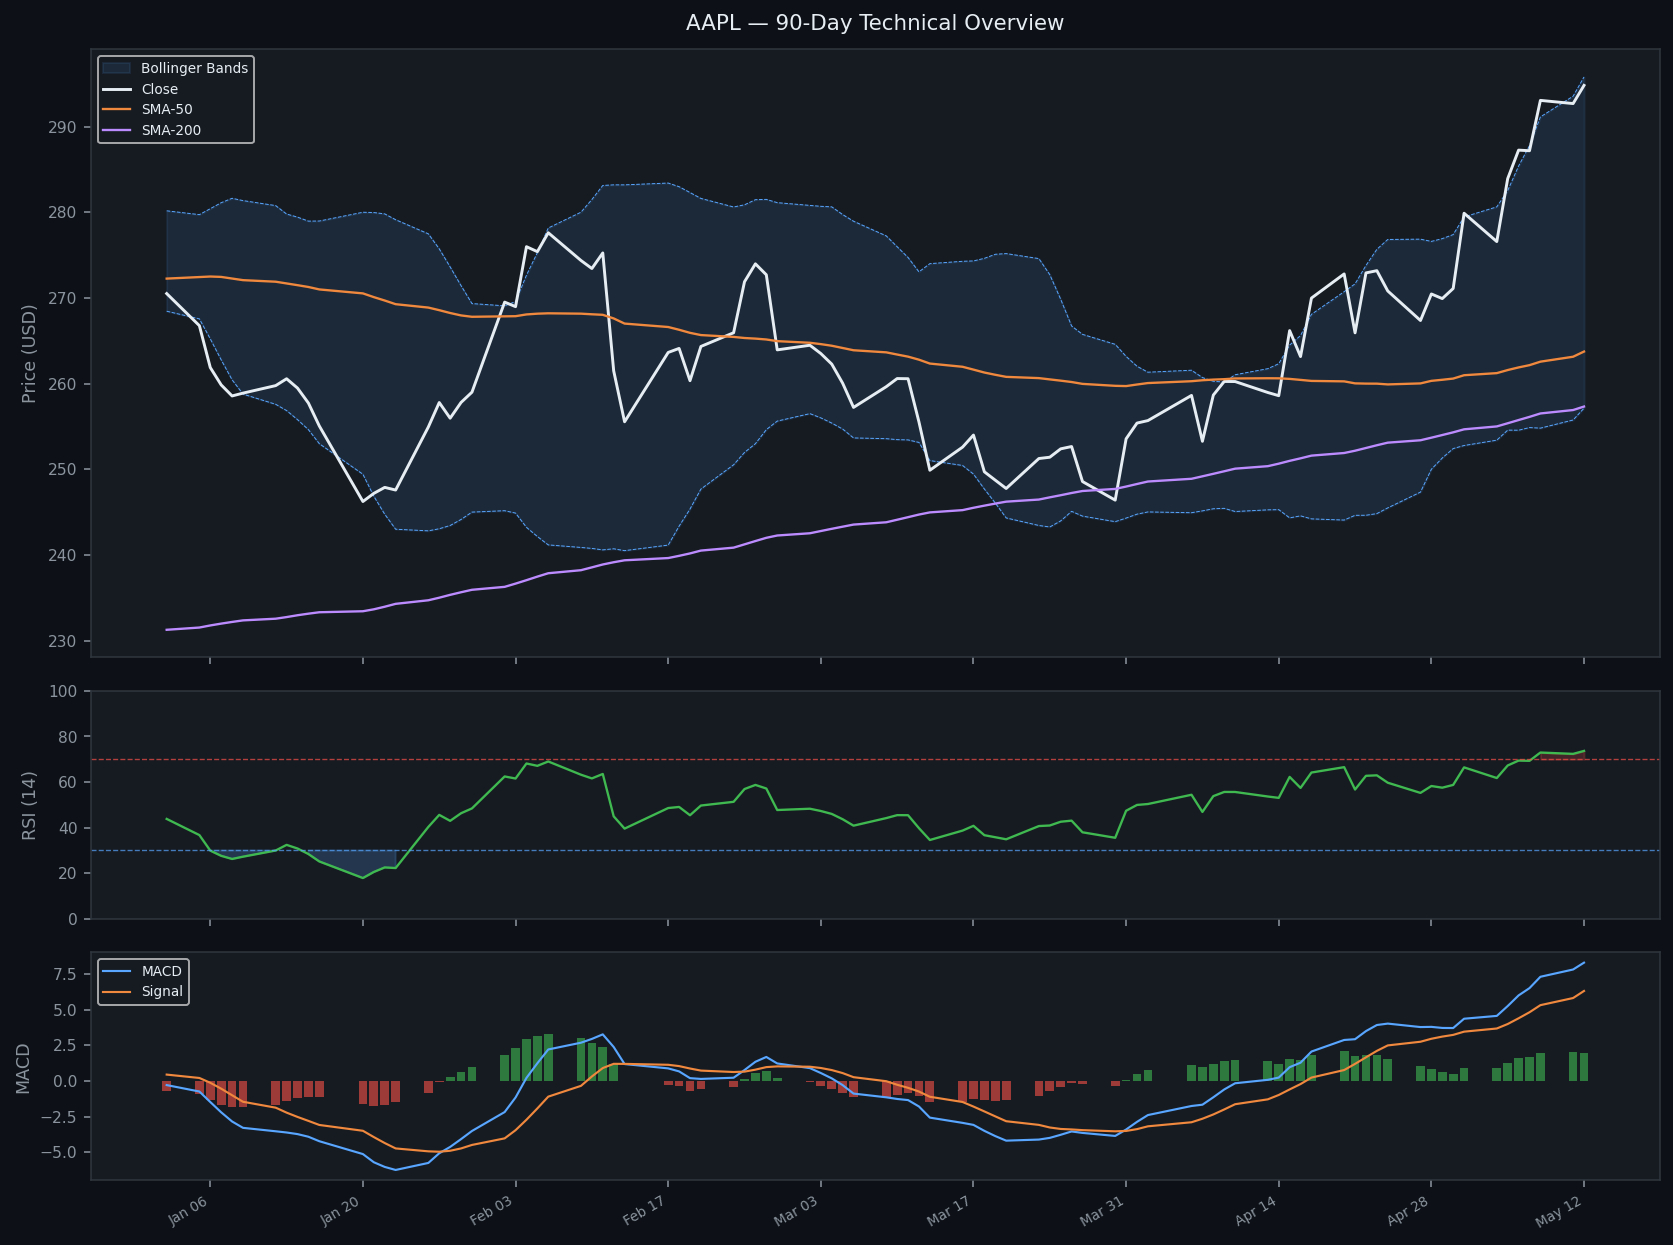

In [14]:
# AI-ASSISTED: Claude (claude-sonnet-4-20250514), Prompt: 'Generate styled HTML equity research brief template with embedded matplotlib base64 chart', Date: 2026-05-13

import base64
from io import BytesIO


def render_price_chart(df: pd.DataFrame, ticker: str) -> str:
    """
    Render a 90-day price chart with SMA-50, SMA-200, and Bollinger Bands.
    Returns the chart as a base64-encoded PNG string for HTML embedding.
    """
    plot_df = df.tail(90).copy()

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9),
                                         gridspec_kw={'height_ratios': [4, 1.5, 1.5]},
                                         sharex=True)
    fig.patch.set_facecolor('#0d1117')
    for ax in (ax1, ax2, ax3):
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#8b949e', labelsize=8)
        ax.spines['bottom'].set_color('#30363d')
        ax.spines['top'].set_color('#30363d')
        ax.spines['left'].set_color('#30363d')
        ax.spines['right'].set_color('#30363d')

    # Price + Bands + SMAs
    ax1.fill_between(plot_df.index, plot_df['BB_Upper'], plot_df['BB_Lower'],
                     alpha=0.1, color='#58a6ff', label='Bollinger Bands')
    ax1.plot(plot_df.index, plot_df['BB_Upper'], color='#58a6ff', linewidth=0.5, linestyle='--')
    ax1.plot(plot_df.index, plot_df['BB_Lower'], color='#58a6ff', linewidth=0.5, linestyle='--')
    ax1.plot(plot_df.index, plot_df['Close'],    color='#e6edf3', linewidth=1.5, label='Close')
    ax1.plot(plot_df.index, plot_df['SMA_50'],   color='#f0883e', linewidth=1.2, label='SMA-50')
    ax1.plot(plot_df.index, plot_df['SMA_200'],  color='#bc8cff', linewidth=1.2, label='SMA-200')
    ax1.set_ylabel('Price (USD)', color='#8b949e', fontsize=9)
    ax1.legend(loc='upper left', fontsize=7, facecolor='#161b22', labelcolor='#e6edf3')
    ax1.set_title(f'{ticker} — 90-Day Technical Overview', color='#e6edf3', fontsize=11, pad=10)

    # RSI panel
    ax2.plot(plot_df.index, plot_df['RSI_14'], color='#3fb950', linewidth=1.2)
    ax2.axhline(70, color='#f85149', linewidth=0.7, linestyle='--', alpha=0.7)
    ax2.axhline(30, color='#58a6ff', linewidth=0.7, linestyle='--', alpha=0.7)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('RSI (14)', color='#8b949e', fontsize=9)
    ax2.fill_between(plot_df.index, plot_df['RSI_14'], 30,
                     where=(plot_df['RSI_14'] < 30), alpha=0.2, color='#58a6ff')
    ax2.fill_between(plot_df.index, plot_df['RSI_14'], 70,
                     where=(plot_df['RSI_14'] > 70), alpha=0.2, color='#f85149')

    # MACD panel
    ax3.plot(plot_df.index, plot_df['MACD'],        color='#58a6ff', linewidth=1.1, label='MACD')
    ax3.plot(plot_df.index, plot_df['MACD_Signal'], color='#f0883e', linewidth=1.1, label='Signal')
    colors = ['#3fb950' if v >= 0 else '#f85149' for v in plot_df['MACD_Hist']]
    ax3.bar(plot_df.index, plot_df['MACD_Hist'], color=colors, alpha=0.6, width=0.8)
    ax3.set_ylabel('MACD', color='#8b949e', fontsize=9)
    ax3.legend(loc='upper left', fontsize=7, facecolor='#161b22', labelcolor='#e6edf3')
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax3.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.xticks(rotation=30, ha='right', color='#8b949e', fontsize=7)

    plt.tight_layout()

    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=140, bbox_inches='tight', facecolor='#0d1117')
    plt.close()
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')


def generate_html_brief(summary: dict,
                         sentiment_results: list[HeadlineSentiment],
                         sentiment_agg: SentimentAggregation,
                         signal: Optional[TradingSignal],
                         ohlcv: pd.DataFrame) -> str:
    """
    Assemble a styled one-page equity research brief in HTML.
    """
    chart_b64 = render_price_chart(ohlcv, summary['ticker'])

    sig_color = {'Buy': '#3fb950', 'Hold': '#f0883e', 'Sell': '#f85149'}
    sig_label = signal.signal if signal else 'N/A'
    sig_col   = sig_color.get(sig_label, '#8b949e')

    top3 = sentiment_results[:3]
    top3_html = ''.join([
        f'<li><span class="badge badge-{h.sentiment}">{h.sentiment.upper()}</span> '
        f'{h.headline} <em>({h.brief_reason})</em></li>'
        for h in top3
    ])

    risks_html = ''.join([f'<li>{r}</li>' for r in (signal.key_risks if signal else [])])

    html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <title>{summary['ticker']} Equity Research Brief</title>
  <link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@400;600&family=IBM+Plex+Sans:wght@300;400;600&display=swap" rel="stylesheet" />
  <style>
    :root {{
      --bg:      #0d1117;
      --surface: #161b22;
      --border:  #30363d;
      --text:    #e6edf3;
      --muted:   #8b949e;
      --green:   #3fb950;
      --yellow:  #f0883e;
      --red:     #f85149;
      --blue:    #58a6ff;
    }}
    * {{ box-sizing: border-box; margin: 0; padding: 0; }}
    body {{ background: var(--bg); color: var(--text); font-family: 'IBM Plex Sans', sans-serif;
            font-size: 13px; line-height: 1.6; padding: 32px; }}
    header {{ border-bottom: 1px solid var(--border); padding-bottom: 16px; margin-bottom: 24px; }}
    header h1 {{ font-size: 26px; font-weight: 600; letter-spacing: -0.5px; }}
    header p  {{ color: var(--muted); font-size: 11px; margin-top: 4px; }}
    .signal-badge {{ display: inline-block; padding: 6px 20px; border-radius: 4px;
                     font-family: 'IBM Plex Mono', monospace; font-size: 18px;
                     font-weight: 600; background: {sig_col}22; color: {sig_col};
                     border: 1px solid {sig_col}55; }}
    .grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-bottom: 20px; }}
    .card {{ background: var(--surface); border: 1px solid var(--border);
             border-radius: 6px; padding: 18px; }}
    .card h2 {{ font-size: 11px; font-weight: 600; text-transform: uppercase;
                letter-spacing: 1.5px; color: var(--muted); margin-bottom: 12px; }}
    .stat-row {{ display: flex; justify-content: space-between;
                 border-bottom: 1px solid var(--border); padding: 6px 0; font-size: 12px; }}
    .stat-row:last-child {{ border-bottom: none; }}
    .stat-val {{ font-family: 'IBM Plex Mono', monospace; color: var(--blue); }}
    .momentum {{ font-family: 'IBM Plex Mono', monospace; font-size: 13px;
                  color: {'var(--green)' if summary['momentum_signal']=='Bullish' else
                           'var(--red)' if summary['momentum_signal']=='Bearish' else 'var(--yellow)'}; }}
    .reasoning {{ color: var(--text); line-height: 1.7; font-size: 12.5px; }}
    ul.risks {{ padding-left: 20px; margin-top: 8px; }}
    ul.risks li {{ margin-bottom: 4px; font-size: 12px; color: var(--muted); }}
    ul.headlines {{ list-style: none; padding: 0; }}
    ul.headlines li {{ border-bottom: 1px solid var(--border); padding: 8px 0;
                       font-size: 12px; color: var(--muted); }}
    ul.headlines li em {{ display: block; font-size: 11px; margin-top: 3px; }}
    .badge {{ display: inline-block; padding: 2px 7px; border-radius: 3px;
              font-family: 'IBM Plex Mono', monospace; font-size: 9px; font-weight: 600;
              margin-right: 6px; }}
    .badge-positive {{ background: #3fb95022; color: #3fb950; }}
    .badge-negative {{ background: #f8514922; color: #f85149; }}
    .badge-neutral  {{ background: #f0883e22; color: #f0883e; }}
    .chart-wrap {{ margin: 20px 0; }}
    .chart-wrap img {{ width: 100%; border-radius: 6px; border: 1px solid var(--border); }}
    .disclaimer {{ margin-top: 20px; padding: 12px 16px; background: #f8514911;
                   border: 1px solid #f8514933; border-radius: 4px;
                   font-size: 10.5px; color: #f85149; line-height: 1.5; }}
    footer {{ margin-top: 24px; color: var(--muted); font-size: 10px; text-align: center; }}
  </style>
</head>
<body>

<header>
  <h1>{summary['ticker']} — {summary['company_name']}</h1>
  <p>Equity Research Brief &nbsp;·&nbsp; Generated {datetime.today().strftime('%B %d, %Y')} &nbsp;·&nbsp;
     Data as of {summary['as_of_date']} &nbsp;·&nbsp; Sector: {summary['sector']}</p>
</header>

<div class="grid">
  <div class="card">
    <h2>Company Snapshot</h2>
    <div class="stat-row"><span>Current Price</span>    <span class="stat-val">${summary['current_price']}</span></div>
    <div class="stat-row"><span>52-Week High</span>     <span class="stat-val">${summary['52w_high']}</span></div>
    <div class="stat-row"><span>52-Week Low</span>      <span class="stat-val">${summary['52w_low']}</span></div>
    <div class="stat-row"><span>P/E Ratio</span>        <span class="stat-val">{summary['pe_ratio'] or 'N/A'}</span></div>
    <div class="stat-row"><span>YTD Return</span>       <span class="stat-val">{summary['ytd_return_pct']}%</span></div>
    <div class="stat-row"><span>SMA-50 / SMA-200</span> <span class="stat-val">${summary['sma_50']} / ${summary['sma_200']}</span></div>
    <div class="stat-row"><span>RSI (14)</span>         <span class="stat-val">{summary['rsi_14']}</span></div>
    <div class="stat-row"><span>Momentum Signal</span>  <span class="momentum">{summary['momentum_signal']}</span></div>
  </div>

  <div class="card">
    <h2>LLM Recommendation</h2>
    <div style="margin-bottom:12px">
      <span class="signal-badge">{sig_label}</span>
      <span style="color:var(--muted); font-size:11px; margin-left:10px">
        Confidence: {f"{signal.confidence:.0%}" if signal else 'N/A'} &nbsp;·&nbsp; {signal.time_horizon if signal else ''}
      </span>
    </div>
    <p class="reasoning">{signal.reasoning if signal else 'Signal unavailable.'}</p>
    {'<h2 style="margin-top:14px">Key Risks</h2><ul class="risks">' + risks_html + '</ul>' if signal else ''}
  </div>
</div>

<div class="chart-wrap">
  <img src="data:image/png;base64,{chart_b64}" alt="{summary['ticker']} Technical Chart" />
</div>

<div class="card" style="margin-bottom:20px">
  <h2>News Sentiment Summary &nbsp;
    <span style="font-size:10px;font-weight:400;color:var(--muted)">
      Overall Score: {sentiment_agg.overall_score:+.2f} &nbsp;·&nbsp;
      {sentiment_agg.positive_count}▲ / {sentiment_agg.neutral_count}● / {sentiment_agg.negative_count}▼
    </span>
  </h2>
  <ul class="headlines">{top3_html}</ul>
</div>

<div class="disclaimer">
  ⚠ <strong>RISK DISCLAIMER:</strong> This report is generated by an automated AI system for
  research and educational purposes only. It does not constitute financial advice, an offer to buy
  or sell any security, or a solicitation of any investment decision. Past performance is not
  indicative of future results. Technical indicators and LLM-generated signals may be incorrect
  or delayed. Always conduct your own due diligence and consult a licensed financial advisor before
  making any investment decisions. The authors accept no liability for trading losses arising from
  reliance on this report.
</div>

<footer>CDAZZDEV MLE Assessment &nbsp;·&nbsp; Task 1 — Financial AI &nbsp;·&nbsp; Candidate: Aasir Waseer</footer>

</body>
</html>
"""
    return html


html_brief = generate_html_brief(summary, sentiment_results, sentiment_agg, trading_signal, ohlcv)

# Save to disk
output_path = 'equity_research_brief.html'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html_brief)

print(f"HTML brief written to: {output_path}")

# Display inline in Colab
try:
    from IPython.display import HTML, display
    display(HTML(html_brief))
except Exception:
    print("(Inline display not available — open equity_research_brief.html in a browser)")

---
## Summary of Deliverables

| Criterion | Status |
|---|---|
| **1A** OHLCV ≥2 years, dynamic dates | ✅ |
| **1A** SMA-50, SMA-200 (first principles) | ✅ |
| **1A** RSI-14 with Wilder smoothing | ✅ |
| **1A** MACD (12,26,9) | ✅ |
| **1A** Bollinger Bands (20, 2σ) | ✅ |
| **1A** ≥10 news headlines (yfinance + RSS fallback) | ✅ |
| **1A** Summary dictionary (all required fields) | ✅ |
| **1A** Null-safe, no magic numbers | ✅ |
| **1B** Per-headline JSON with all 4 fields | ✅ |
| **1B** Aggregated sentiment score | ✅ |
| **1B** Reasoned Buy/Hold/Sell (3-5 sentences, indicator combinations) | ✅ |
| **1B** Pydantic validation + failure logging | ✅ |
| **1B** Prompt constants separated from business logic | ✅ |
| **Bonus** HTML report: snapshot, technicals, sentiment, signal, disclaimer | ✅ |
| **Bonus** Embedded matplotlib chart (price + RSI + MACD) | ✅ |